<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit6/SamaBhatU6proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

In [46]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pmw
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

# Unit 6 Project: You Want To Win? Here's some Gold!

I don't know a crazy amount about this topic, but it seems like it's an interesting topic to analyze. In recent years, the global economy has been kind of a mess as a result of the pandemic a couple years back, but it's starting to recover. In times of uncertainty, there's only 1 primary indicator for the value of a currency amid inflation: Gold. Across history, practically every civilization in history has found some monetary value in gold, so I wanted to analyze that relationship with respect to other currencies to gain an understanding of the interactions happening in the global economy.



Let us begin by loading in the data. I got this from [kaggle](https://www.kaggle.com/datasets/rizkykiky/gold-price-dataset?select=Monthly_Avg.csv), but I think it's pretty good data.

In [47]:
url = "https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit6/Monthly_Avg.csv"

full_data = pd.read_csv(url)
full_data

,Date,USD,EUR,JPY,GBP,CAD,CHF,INR,CNY,TRY,SAR,IDR,AED,THB,VND,EGP,KRW,RUB,ZAR,AUD
0,1/31/1978,207.8,129.2,NaN,104.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2/28/1978,227.3,139.5,"44,853.1",113.3,269.5,378.8,"1,852.8",NaN,NaN,754.1,"141,796.4",869.4,"4,582.2",NaN,NaN,"111,186.6",NaN,197.0,198.6
2,3/31/1978,245.7,151.3,"49,213.2",122.5,293.2,410.6,"2,010.4",NaN,NaN,822.3,"153,099.6",939.1,"4,949.5",NaN,NaN,"118,284.0",NaN,209.9,216.7
3,4/28/1978,242.1,149.3,"49,989.4",118.8,284.2,407.3,"1,974.9",NaN,NaN,810.1,"151,068.5",926.2,"4,884.5",NaN,NaN,"116,507.1",NaN,204.4,215.9
4,5/31/1978,239.2,148.8,"51,707.2",115.4,274.2,410.5,"1,960.9",NaN,NaN,817.3,"149,744.3",919.9,"4,842.6",NaN,NaN,"115,555.9",NaN,202.8,215.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,2/28/2023,"1,854.5","1,732.6","246,704.0","1,534.6","2,494.4","1,716.5","153,245.7","12,684.8","34,952.6","6,958.1","28,102,320.8","6,811.7","63,209.4","43,811,565.0","56,544.2","2,371,350.6","136,450.3","33,207.8","2,688.9"
542,3/31/2023,"1,912.7","1,785.6","255,594.1","1,574.9","2,616.6","1,770.8","157,347.7","13,183.2","36,363.1","7,182.3","29,219,135.0","7,024.8","65,917.8","45,150,049.3","59,020.5","2,495,478.4","146,196.0","34,928.6","2,865.7"
543,4/28/2023,"2,000.4","1,823.5","267,106.3","1,606.6","2,696.9","1,795.4","163,940.8","13,781.6","38,715.9","7,503.4","29,756,046.9","7,346.1","68,486.9","46,954,718.2","61,802.9","2,648,463.2","162,662.9","36,357.5","2,988.9"
544,5/31/2023,"1,990.2","1,833.4","272,911.0","1,595.3","2,691.1","1,787.2","163,859.5","13,916.0","39,355.1","7,464.0","29,535,796.7","7,308.5","68,102.0","46,701,669.7","61,518.5","2,643,769.5","157,892.8","38,025.1","2,998.3"


As expected from kaggle data, there are a lot of NaN values, so I'll remove those. A better dataset from a more reputable source wouldn't have these missing values. I'll also make sure that all the columns are specified as numeric, since I was having difficulty with loading the pairplot without doing this.

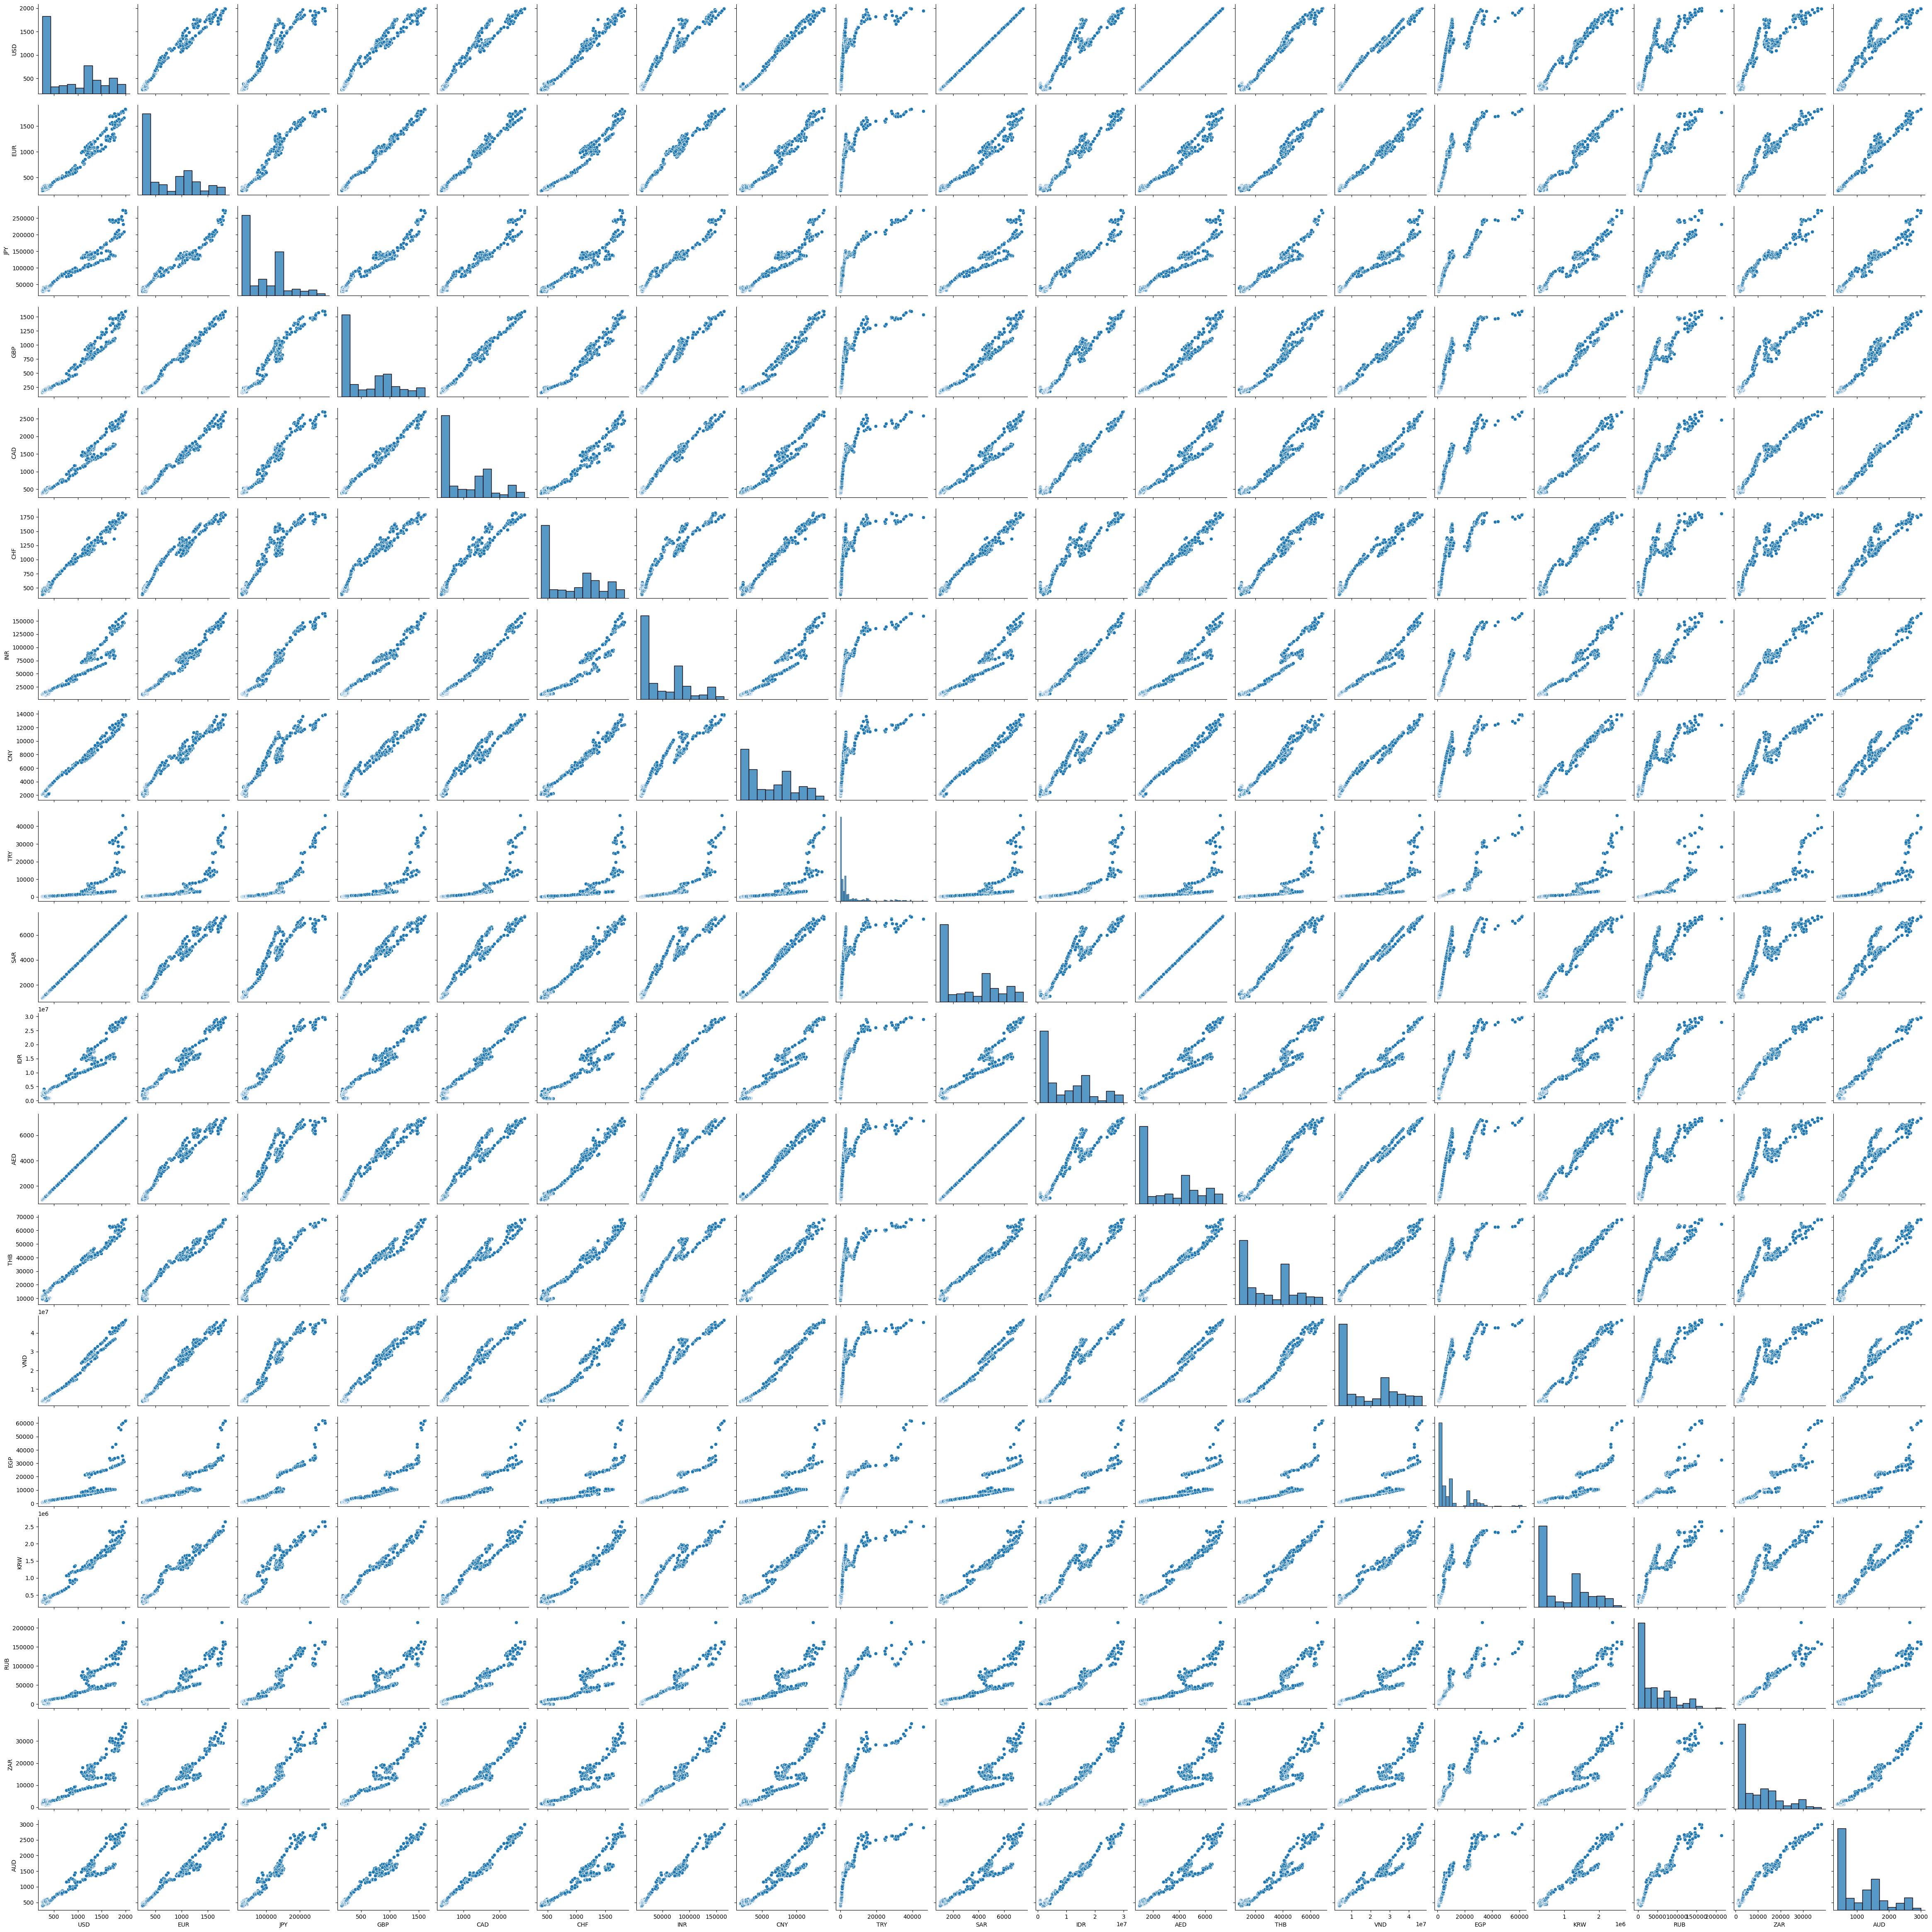

In [48]:
# Make a copy of the dataset
full_data = full_data.dropna()
df_plot = full_data.copy()

# All the columns in the dataset: needs to be turned into numeric variables
currency_columns = ['USD', 'EUR', 'JPY', 'GBP', 'CAD', 'CHF', 'INR', 'CNY', 'TRY', 'SAR',
                    'IDR', 'AED', 'THB', 'VND', 'EGP', 'KRW', 'RUB', 'ZAR', 'AUD']

# Clean and convert these columns to numeric (Thank you Gemini)
for col in currency_columns:
    if col in df_plot.columns and df_plot[col].dtype == 'object':
        df_plot[col] = df_plot[col].str.replace(',', '', regex=False)
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce') # coerce errors will turn unparseable values into NaN

# Select only numeric columns for pairplot
numeric_df_plot = df_plot.select_dtypes(include=np.number)


sns.pairplot(numeric_df_plot)


Well look at that! Approximately linear relationships across the board!

Let's begin by making a causal diagram to develop a reference model. I only chose Chinese Yuan, Euro, and Great Britain Pound as priors predictors because I feel that they are some of the most significant currencies across the world.

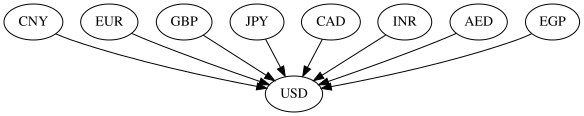

In [53]:
dag_b = gv.Digraph(comment='gold_dag') #b for bikes

dag_b.node('C', 'CNY')
dag_b.node('U','USD')
dag_b.node('E','EUR')
dag_b.node('G','GBP')
dag_b.node('X','JPY')
dag_b.node('Y','CAD')
dag_b.node('Z','INR')
dag_b.node('A','AED')
dag_b.node('B','EGP')




dag_b.edges(['CU','EU','GU','XU','YU','ZU','AU','BU'])

dag_b

I feel like a guassian likelihood fits well for this data. It's continuous, and bambi has the gaussian default anyways. I have a lot of variables to choose from! I know this might be a bad choice, but to avoid excess divergences, I'm going to cut out the currencies I don't know.

In [50]:
gold_reference = bmb.Model("'USD' ~ 'CNY' + 'EUR' + 'GBP' + 'JPY' + 'CAD' + 'INR' + 'AED' + 'EGP'" , df_plot, family="gaussian")

In [ ]:
idata_gold_refernece = gold_reference.fit(idata_kwargs={"log_likelihood":True})

In [56]:
gold_reference

       Formula: 'USD' ~ 'CNY' + 'EUR' + 'GBP' + 'JPY' + 'CAD' + 'INR' + 'AED' + 'EGP'
        Family: gaussian
          Link: mu = identity
  Observations: 377
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 881.7329, sigma: 5939.8482)
            CNY ~ Normal(mu: 0.0, sigma: 0.4035)
            EUR ~ Normal(mu: 0.0, sigma: 2.9473)
            GBP ~ Normal(mu: 0.0, sigma: 3.2553)
            JPY ~ Normal(mu: 0.0, sigma: 0.0229)
            CAD ~ Normal(mu: 0.0, sigma: 2.0993)
            INR ~ Normal(mu: 0.0, sigma: 0.0325)
            AED ~ Normal(mu: 0.0, sigma: 0.6806)
            EGP ~ Normal(mu: 0.0, sigma: 0.1213)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 557.7371)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

Now I need to create a couple more models to compare to this reference using elpd_loo. I'm going to try and go off of both assumptions and my (minimal) prior knowledge about this topic.

## **MODEL 1: INTERACTIONS BETWEEN ALL PREDICTORS**

As depicted on the pairplot at the top of this notebook, *every single predictor* is related amongst one another. This means that having all of them interact is a justified model design choice.

In [64]:
model1 = bmb.Model("'USD' ~ 'CNY' + 'EUR' + 'GBP' + 'CAD' + 'INR' + 'AED' + 'AED':'EGP' + 'CNY':'JPY' + 'EUR':'GBP' " , df_plot, family="gaussian")

In [ ]:
idata_model1 = model1.fit(idata_kwargs={"log_likelihood":True})

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

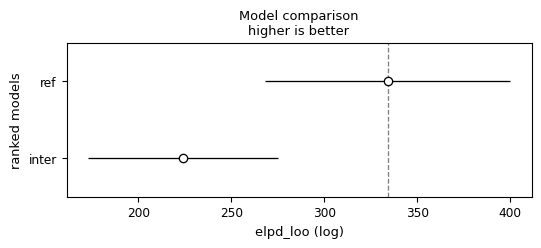

In [66]:
q = az.compare({"ref": idata_gold_refernece, "inter": idata_model1})
az.plot_compare(q)